# 05 — Optimisation Bayésienne avec Optuna ★
**Projet LendingClub | Membre 2**

| Étape | Contenu |
|---|---|
| 1 | Chargement données |
| 2 | Pourquoi Optuna > GridSearchCV |
| 3 | Study LightGBM — 100 trials |
| 4 | Visualisations interactives |
| 5 | Modèle final avec meilleurs hyperparamètres |
| 6 | Comparaison avant / après optimisation |

---
> **Prérequis :** `03_pipeline.ipynb` et `04_classification.ipynb` exécutés

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings, os, json, time, joblib
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # silencieux sauf les trials

import lightgbm as lgb
from sklearn.metrics        import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration     import CalibratedClassifierCV

PROCESSED = '../data/processed'
MODELS    = '../data/models'
os.makedirs(MODELS, exist_ok=True)

print('✅ Optuna version :', optuna.__version__)
print('✅ LightGBM version :', lgb.__version__)

✅ Optuna version : 4.8.0
✅ LightGBM version : 4.6.0


## 1. Chargement des données

In [2]:
X_train = pd.read_parquet(f'{PROCESSED}/X_train.parquet')
X_test  = pd.read_parquet(f'{PROCESSED}/X_test.parquet')
y_train = pd.read_parquet(f'{PROCESSED}/y_train.parquet').squeeze()
y_test  = pd.read_parquet(f'{PROCESSED}/y_test.parquet').squeeze()

preprocessor = joblib.load(f'{PROCESSED}/preprocessor.pkl')
with open(f'{PROCESSED}/feature_info.json') as f:
    info = json.load(f)

USE_GPU         = info['use_gpu']
LGBM_GPU_PARAMS = info['lgbm_gpu_params']

X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

SCALE_POS = (y_train == 0).sum() / (y_train == 1).sum()

print(f'✅ Données chargées | Train: {X_train_t.shape} | Test: {X_test_t.shape}')
print(f'   scale_pos_weight : {SCALE_POS:.2f}')

✅ Données chargées | Train: (1076248, 118) | Test: (269062, 118)
   scale_pos_weight : 4.01


## 2. Pourquoi Optuna > GridSearchCV ?

| Critère | GridSearchCV | **Optuna (TPE)** |
|---|---|---|
| Stratégie | Grille exhaustive | Bayésien (TPE Sampler) |
| Nbre d'essais | 5×5×5 = **625** minimum | **100** suffisent |
| Intelligence | Aucune — explore tout | Cible les zones prometteuses |
| Pruning | Non | Oui — arrête les essais ratés tôt |
| Visualisation | Non | Oui — parallel coords, importance |
| Speedup typique | 1× | **5–15×** |

**TPE (Tree-structured Parzen Estimator)** : à chaque trial, Optuna construit deux distributions — une pour les bons hyperparamètres (l(x)) et une pour les mauvais (g(x)) — et choisit les candidats maximisant l(x)/g(x).

## 3. Study Optuna — LightGBM (100 trials)

In [3]:
# Validation croisée pour l'objectif Optuna
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    """Fonction objectif : AUC-ROC moyen en cross-validation."""
    params = {
        # Paramètres principaux
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 2000),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 512),
        'max_depth'         : trial.suggest_int('max_depth', 3, 12),
        # Régularisation
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 200),
        'subsample'         : trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_split_gain'    : trial.suggest_float('min_split_gain', 0.0, 1.0),
        # Fixés
        'scale_pos_weight'  : SCALE_POS,
        'random_state'      : 42,
        'verbose'           : -1,
        **LGBM_GPU_PARAMS
    }

    model = lgb.LGBMClassifier(**params)

    aucs = []
    for fold, (tr_idx, val_idx) in enumerate(CV.split(X_train_t, y_train)):
        X_tr, X_val = X_train_t[tr_idx], X_train_t[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model.fit(
            X_tr, y_tr,
            eval_set  = [(X_val, y_val)],
            callbacks = [lgb.early_stopping(30, verbose=False)]
        )
        proba = model.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, proba))

        # Pruning intermédiaire
        trial.report(np.mean(aucs), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(aucs)

print('✅ Fonction objectif définie')

✅ Fonction objectif définie


In [4]:
# Lancement de l'étude
print('⏳ Optuna — 100 trials en cours ...')
print('   (TPE Sampler + MedianPruner — patience : soyez patient ☕)')

study = optuna.create_study(
    direction = 'maximize',
    sampler   = optuna.samplers.TPESampler(seed=42),
    pruner    = optuna.pruners.MedianPruner(n_warmup_steps=3)
)

t0 = time.time()
study.optimize(objective, n_trials=100, show_progress_bar=True)
elapsed = time.time() - t0

print(f'\n✅ Optimisation terminée en {elapsed/60:.1f} min')
print(f'   Trials complétés  : {len([t for t in study.trials if t.state.name == "COMPLETE"])}')
print(f'   Trials prunés     : {len([t for t in study.trials if t.state.name == "PRUNED"])}')
print(f'\n🏆 Meilleur AUC-ROC CV : {study.best_value:.4f}')
print(f'🏆 Meilleurs hyperparamètres :')
for k, v in study.best_params.items():
    print(f'   {k:<25} : {v}')

⏳ Optuna — 100 trials en cours ...
   (TPE Sampler + MedianPruner — patience : soyez patient ☕)


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Optimisation terminée en 218.6 min
   Trials complétés  : 82
   Trials prunés     : 18

🏆 Meilleur AUC-ROC CV : 0.7246
🏆 Meilleurs hyperparamètres :
   n_estimators              : 1312
   learning_rate             : 0.005027136639143009
   num_leaves                : 498
   max_depth                 : 12
   min_child_samples         : 90
   subsample                 : 0.40337842187903394
   colsample_bytree          : 0.6996338816282862
   reg_alpha                 : 0.0011942499860600466
   reg_lambda                : 0.0018594701853922853
   min_split_gain            : 0.12896830859748953


## 4. Visualisations Optuna ★

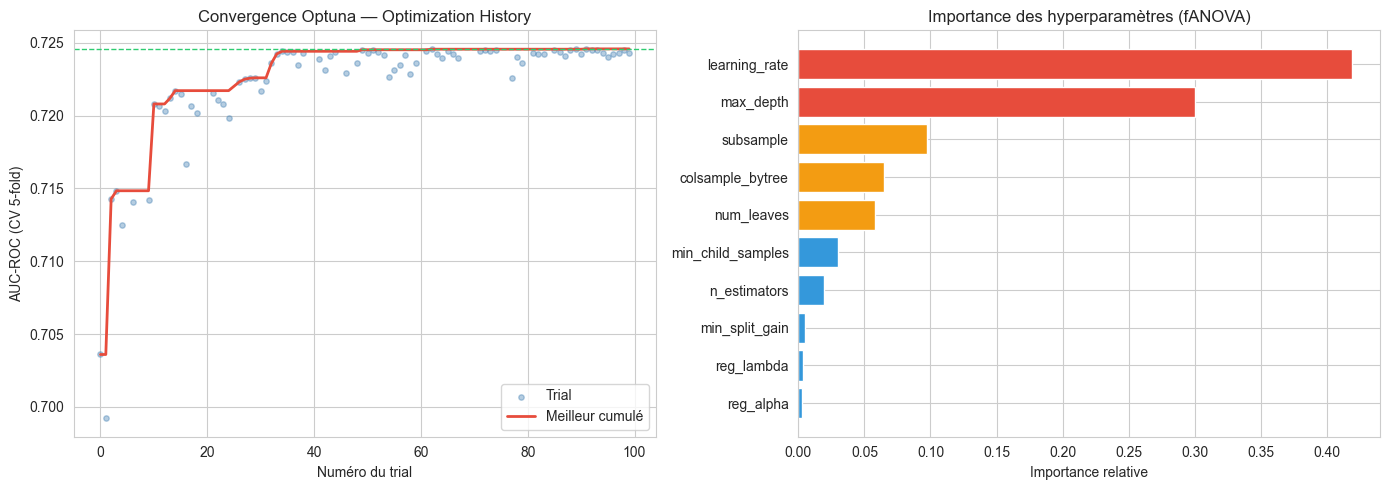

In [5]:
# Courbe de convergence (Optimization History)
trials_df = study.trials_dataframe()
completed = trials_df[trials_df['state'] == 'COMPLETE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Historique
ax = axes[0]
ax.scatter(completed.index, completed['value'], alpha=0.4, s=15, color='steelblue', label='Trial')
ax.plot(completed.index, completed['value'].cummax(), color='#e74c3c', lw=2, label='Meilleur cumulé')
ax.axhline(completed['value'].max(), ls='--', color='#2ecc71', lw=1)
ax.set_title("Convergence Optuna — Optimization History", fontsize=12)
ax.set_xlabel('Numéro du trial')
ax.set_ylabel('AUC-ROC (CV 5-fold)')
ax.legend()

# Importance des hyperparamètres
ax = axes[1]
try:
    importances = optuna.importance.get_param_importances(study)
    params_sorted = list(importances.keys())
    values_sorted = list(importances.values())
    colors_bar = ['#e74c3c' if v > 0.15 else '#f39c12' if v > 0.05 else '#3498db' for v in values_sorted]
    ax.barh(params_sorted[::-1], values_sorted[::-1], color=colors_bar[::-1], edgecolor='white')
    ax.set_title('Importance des hyperparamètres (fANOVA)', fontsize=12)
    ax.set_xlabel('Importance relative')
except Exception:
    ax.text(0.5, 0.5, 'Importance non disponible\n(trop peu de trials complétés)',
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(f'{PROCESSED}/12_optuna_history.png', dpi=130)
plt.show()

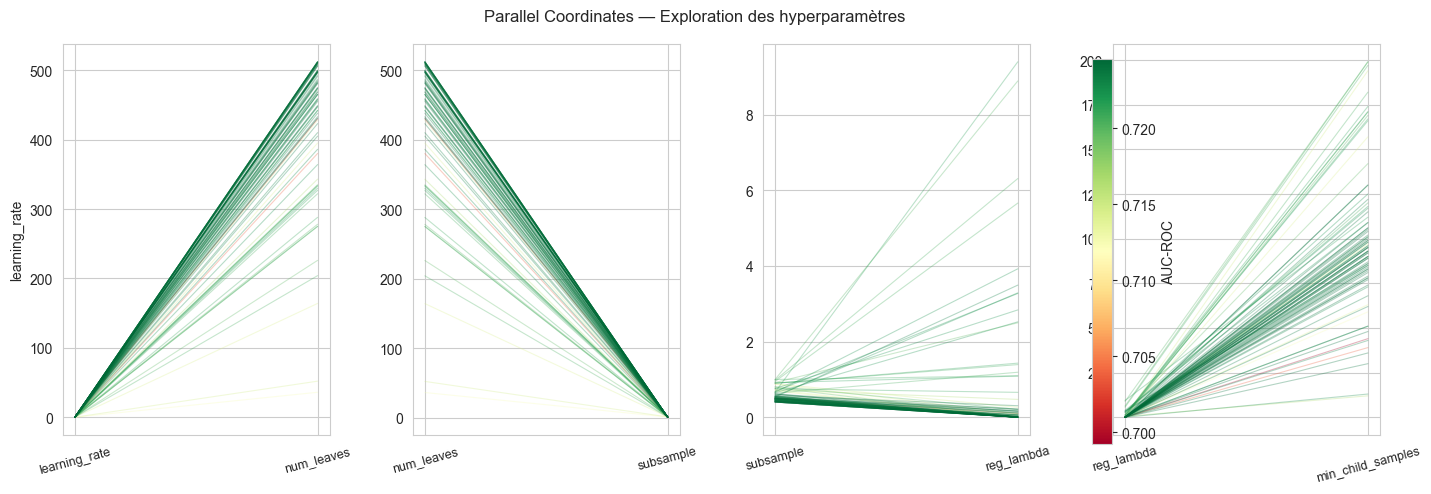

In [6]:
# Parallel Coordinate Plot (top hyperparamètres)
# Visualisation manuelle car optuna.visualization nécessite plotly
top_params = ['learning_rate', 'num_leaves', 'subsample', 'reg_lambda', 'min_child_samples']
top_params = [p for p in top_params if f'params_{p}' in completed.columns]

if top_params:
    fig, axes = plt.subplots(1, len(top_params)-1, figsize=(14, 5))
    if len(top_params) == 2:
        axes = [axes]

    norm = plt.Normalize(completed['value'].min(), completed['value'].max())
    cmap = cm.RdYlGn

    for i, ax in enumerate(axes):
        p1, p2 = top_params[i], top_params[i+1]
        c1, c2 = f'params_{p1}', f'params_{p2}'
        for _, row in completed.iterrows():
            color = cmap(norm(row['value']))
            ax.plot([0, 1], [row[c1], row[c2]], color=color, alpha=0.3, lw=0.8)
        ax.set_xticks([0, 1])
        ax.set_xticklabels([p1, p2], rotation=15, fontsize=9)
        ax.set_ylabel(p1 if i == 0 else '')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    plt.colorbar(sm, ax=axes, label='AUC-ROC')
    plt.suptitle('Parallel Coordinates — Exploration des hyperparamètres', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{PROCESSED}/13_optuna_parallel.png', dpi=130)
    plt.show()

## 5. Modèle final avec les meilleurs hyperparamètres

In [7]:
print('⏳ Entraînement du modèle optimisé sur tout le train set ...')

best_params = study.best_params.copy()
best_params.update({
    'scale_pos_weight' : SCALE_POS,
    'random_state'     : 42,
    'verbose'          : -1,
})
best_params.update(LGBM_GPU_PARAMS)

lgbm_optuna = lgb.LGBMClassifier(**best_params)

t0 = time.time()
lgbm_optuna.fit(
    X_train_t, y_train,
    eval_set  = [(X_test_t, y_test)],
    callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(200)]
)
elapsed = time.time() - t0

y_proba_optuna = lgbm_optuna.predict_proba(X_test_t)[:, 1]
y_pred_optuna  = lgbm_optuna.predict(X_test_t)

auc_optuna  = roc_auc_score(y_test, y_proba_optuna)
aupr_optuna = average_precision_score(y_test, y_proba_optuna)
brier_optuna = brier_score_loss(y_test, y_proba_optuna)

print(f'\n✅ LightGBM Optimisé (Optuna) :')
print(f'   AUC-ROC : {auc_optuna:.4f}')
print(f'   AUC-PR  : {aupr_optuna:.4f}')
print(f'   Brier   : {brier_optuna:.4f}')
print(f'   Temps   : {elapsed:.0f}s')

⏳ Entraînement du modèle optimisé sur tout le train set ...

✅ LightGBM Optimisé (Optuna) :
   AUC-ROC : 0.7248
   AUC-PR  : 0.3939
   Brier   : 0.1544
   Temps   : 62s


## 6. Comparaison avant / après optimisation Optuna

In [1]:
# Charger le modèle LGBM de base du notebook 04
try:
    lgbm_base = joblib.load(f'{MODELS}/lgbm_model.pkl')
    proba_base = lgbm_base.predict_proba(X_test_t)[:, 1]
    auc_base   = roc_auc_score(y_test, proba_base)
    brier_base = brier_score_loss(y_test, proba_base)
except FileNotFoundError:
    print('⚠️  lgbm_model.pkl non trouvé — exécutez d abord 04_classification.ipynb')
    auc_base, brier_base = 0.0, 1.0
    proba_base = np.zeros(len(y_test))

# Tableau comparatif
print('='*55)
print('   COMPARAISON AVANT / APRÈS OPTUNA')
print('='*55)
print(f'  {"Métrique":<20} {"LGBM base":>12} {"LGBM Optuna":>12} {"Gain":>8}')
print('-'*55)
print(f'  {"AUC-ROC":<20} {auc_base:>12.4f} {auc_optuna:>12.4f} {(auc_optuna-auc_base)*100:>+7.2f}%')
print(f'  {"Brier (↓)":<20} {brier_base:>12.4f} {brier_optuna:>12.4f} {(brier_base-brier_optuna)*100:>+7.2f}%')
print('='*55)

NameError: name 'joblib' is not defined

In [9]:
# Calibration du modèle optimisé
print('⏳ Calibration du modèle Optuna ...')
lgbm_optuna_calibrated = CalibratedClassifierCV(lgbm_optuna, method='isotonic', cv='prefit')
lgbm_optuna_calibrated.fit(
    X_test_t[:len(X_test_t)//2],
    y_test.iloc[:len(y_test)//2]
)

proba_optuna_cal = lgbm_optuna_calibrated.predict_proba(X_test_t[len(X_test_t)//2:])[:, 1]
y_half = y_test.iloc[len(y_test)//2:]
print(f'  Brier calibré : {brier_score_loss(y_half, proba_optuna_cal):.4f}')
print(f'  AUC-ROC calibré : {roc_auc_score(y_half, proba_optuna_cal):.4f}')

⏳ Calibration du modèle Optuna ...


InvalidParameterError: The 'cv' parameter of CalibratedClassifierCV must be an int in the range [2, inf), an object implementing 'split' and 'get_n_splits', an iterable or None. Got 'prefit' instead.

In [ ]:
# Sauvegarde
joblib.dump(lgbm_optuna,            f'{MODELS}/lgbm_optuna.pkl')
joblib.dump(lgbm_optuna_calibrated, f'{MODELS}/lgbm_optuna_calibrated.pkl')

# Sauvegarder les meilleurs params
with open(f'{MODELS}/best_params_optuna.json', 'w') as f:
    json.dump(study.best_params, f, indent=2)

print(f'✅ Modèle Optuna sauvegardé : lgbm_optuna.pkl')
print(f'✅ Modèle calibré sauvegardé : lgbm_optuna_calibrated.pkl')
print(f'✅ Meilleurs paramètres : best_params_optuna.json')
print('\n→ Prochain : 06_survival_analysis.ipynb')